# Citation Network Paper Classification with Cora

Classifies research papers into one of **seven topics** using both paper-word features and citation relationships.


We compare two approaches:

| Approach
----------------------
| Random Forest baseline
| Two-layer GCN

# Dataset: Cora

In this project, we are using a **prebuilt graph dataset called Cora**.

The Cora dataset contains **scientific research papers** and the **citation relationships between those papers**.

---

##How is the dataset represented?

We represent the dataset as a **graph**.

```text
Research Paper A  ─────►  Research Paper B
        ●                       ●
      Node                    Node

## 1. Install and import packages

In [1]:
%pip install torch torch-geometric scikit-learn pandas matplotlib seaborn networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid

Note: you may need to restart the kernel to use updated packages.


/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/Research_Topic_Classification/.venv-nb/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/private/tmp/claude-501/-Users-sumitjadhav-portfolio/87809726-a65c-4ea3-bf5f-272507e05bb2/scratchpad/fix/Research_Topic_Classification/.venv-nb/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 2. Load the Cora citation graph

`Planetoid` is the PyTorch Geometric dataset wrapper for Cora, CiteSeer, and PubMed [4]. Each paper is a node, each citation is an edge, `x` contains node features, and `y` contains topic labels. The provided masks define the train, validation, and test nodes.

In [2]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [3]:
dataset = Planetoid(root="data/Planetoid", name="Cora")

data = dataset[0]

print(f"Numbers of Papers (Nodes): {data.num_nodes}")
print(f"Numbers of Citations (Edges): {data.num_edges}")
print(f"Features per paper : {data.num_node_features}")
print(f"Number of topics: {dataset.num_classes}")
print(f"Training Papers: {data.train_mask.sum()}")
print(f"Validation Papers: {data.val_mask.sum()}")
print(f"Testing Papers: {data.test_mask.sum()}")

Numbers of Papers (Nodes): 2708
Numbers of Citations (Edges): 10556
Features per paper : 1433
Number of topics: 7
Training Papers: 140
Validation Papers: 500
Testing Papers: 1000


In [4]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

## 3. Inspect citation-network structure

A node degree is the number of edges connected to a paper. Degree is a simple graph feature: highly connected papers may be more central to their topic, although degree alone is not enough for classification.

<Axes: xlabel='None', ylabel='count'>

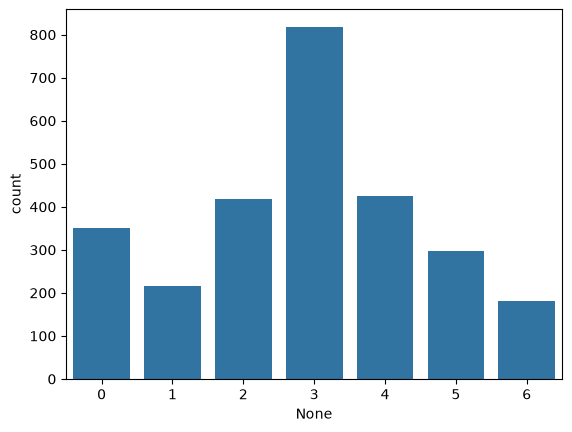

In [5]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

sns.barplot(x=topic_counts.index, y=topic_counts)

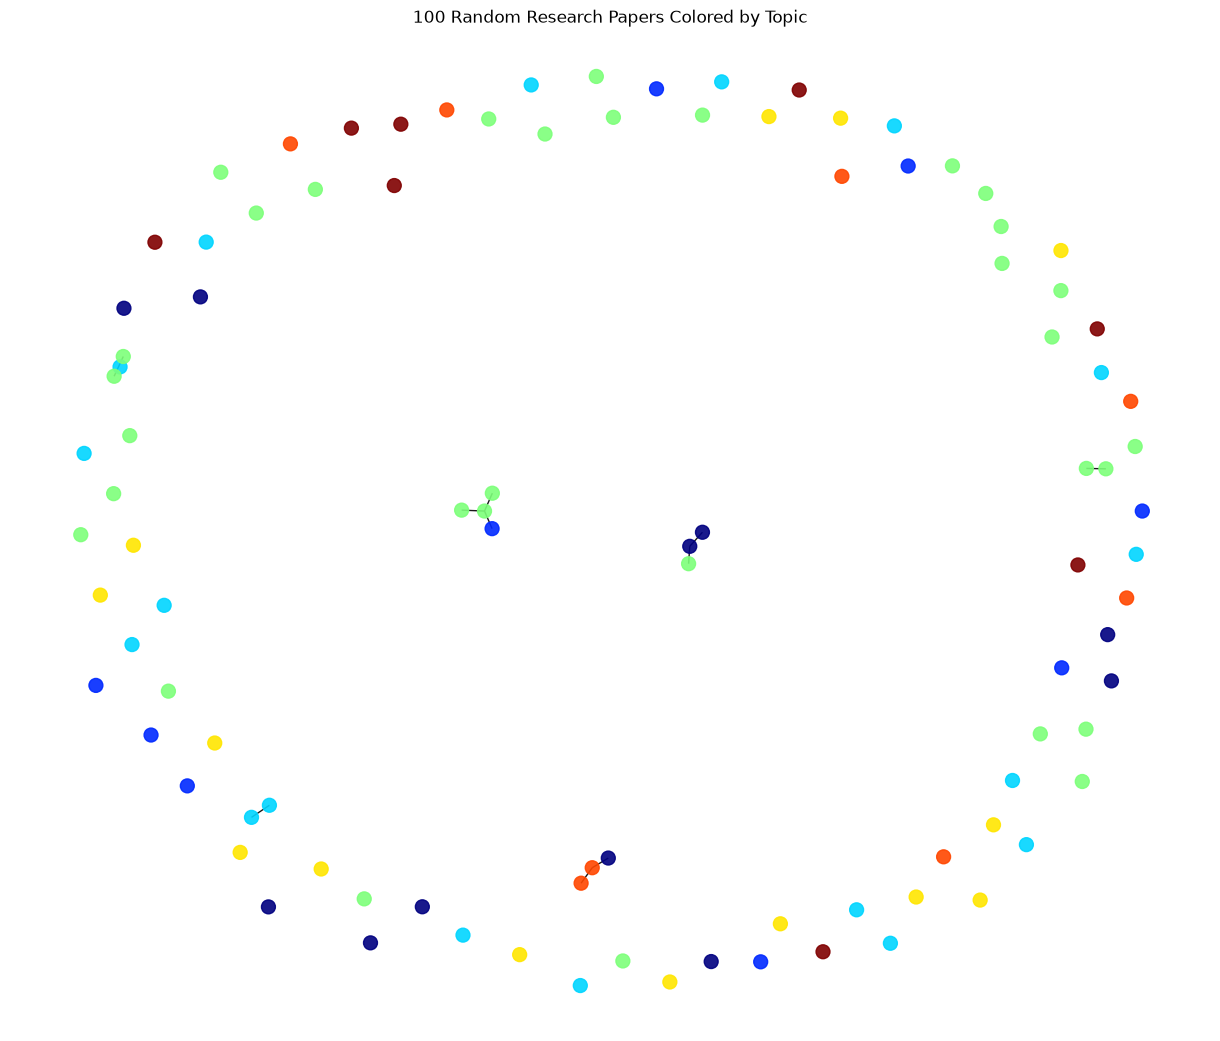

In [6]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

## 4. Baseline: TF-IDF-style features plus Random Forest

The Cora features are binary indicators for whether a vocabulary word appears in a paper. `TfidfTransformer` reweights these columns so that words occurring in many papers receive less emphasis. We then add two easy graph features: degree and log-degree.

This is a fair educational baseline, but it is not a text model trained on raw abstracts. Its purpose is to answer: **How well can we classify papers without message passing across the graph?**

In [7]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [8]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [9]:
#Reweight he supplies word indicators.
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf #Features

train_idx = data.train_mask.numpy() #Training Research Papers
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train , y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx],y[test_idx]

rf = RandomForestClassifier(n_estimators=100,max_features="sqrt",class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [10]:
#Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")

Accuracy: 0.5810
Macro-F1: 0.5698


<Axes: >

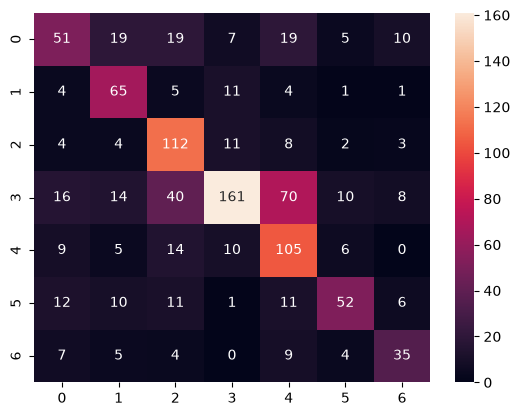

In [11]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")

## 5. Advanced model: a simple two-layer GCN

A GCN updates each paper by combining its own features with information from neighboring papers. In this notebook, the model has only two graph-convolution layers, a ReLU activation, and
dropout. This keeps the code readable while demonstrating the central idea of graph neural networks.

`GCNConv` is PyTorch Geometric's implementation of the graph convolution operator [5].

In [12]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch

class SimpleGCN(nn.Module):
  def __init__(self, input_dim,hidden_dim,output_dim,dropout=0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim,output_dim)
    self.dropout = dropout

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x

model = SimpleGCN(
    input_dim = data.num_features,
    hidden_dim = 32,
    output_dim = dataset.num_classes,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [13]:
# Research Paper A -> 0, 1, 2, 3, 4, 5, 6

In [14]:
#Training of GCN Model
def train_one_epoch():
    model.train() #Training
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index) #x-> 2708 x 7
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index) # Pass full edge_index to the model
    predictions = logits.argmax(dim=1)
    accuracy = (predictions[mask] == data.y[mask]).float().mean().item() # Corrected accuracy calculation
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro"
    )
    return accuracy, macro_f1, predictions

In [15]:
# evaluate(data.train_mask)


In [16]:
import copy

losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 #Stop i no improvement for this many epochs

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy) #0.70

  if val_accuracy > best_val_accuracy: #0.56 > 0.70
    best_val_accuracy = val_accuracy
    # state_dict() returns live references to the parameters, so keep a copy or the
    # "best" state silently tracks every later epoch too.
    best_state = copy.deepcopy(model.state_dict())
    epoch_without_improvement = 0

  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} |Best Val Acc: {best_val_accuracy:.4f}")

model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-F1: {gcn_f1:.3f}")

Epoch: 001 | Loss: 1.9439 | Train Acc: 0.7143 | Val Acc: 0.4020 |Best Val Acc: 0.4020


Epoch: 010 | Loss: 0.4396 | Train Acc: 0.9857 | Val Acc: 0.7860 |Best Val Acc: 0.7860


Epoch: 020 | Loss: 0.0567 | Train Acc: 1.0000 | Val Acc: 0.7740 |Best Val Acc: 0.7880


Epoch: 030 | Loss: 0.0244 | Train Acc: 1.0000 | Val Acc: 0.7600 |Best Val Acc: 0.7880
Early stopping at epoch 31



GCN test accuracy: 0.815
GCN test macro-F1: 0.808


## 6. Compare the models

Accuracy is the fraction of correct predictions. Macro-F1 gives every topic equal importance, which is useful when class sizes differ. The exact result can vary slightly across hardware, package versions, and training runs.

<Axes: >

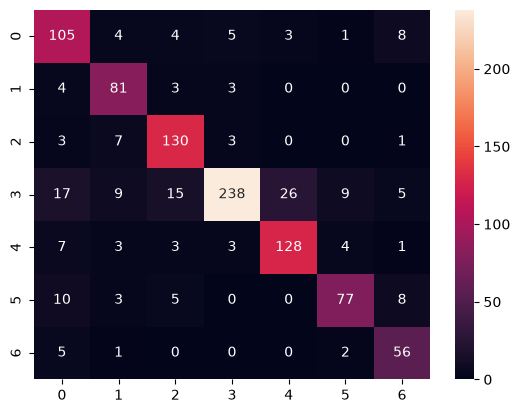

In [17]:
#Confusion MArix for GCN model.
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(), gcn_pred[data.test_mask].numpy()),
    annot=True,
    fmt="d"
)

In [18]:
results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro-F1": [rf_f1, gcn_f1]
})

In [19]:
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.581,0.569807
1,GCN,0.815,0.807975


## 7. What did we learn?

The Random Forest uses each paper's features independently, with degree as a small amount of graph context. The GCN performs **message passing**, allowing a paper's representation to be influenced by connected papers. When the GCN performs better, the result suggests that citation structure contains useful information about research topics.

However, this is not proof that citations cause topic membership. The graph may contain homophily, dataset artifacts, or information leakage through the standard benchmark split. For a stronger project, try CiteSeer or PubMed, compare different random seeds, report mean and standard deviation over several runs, and test a model using only graph features.

In [20]:
#ONNX -> Open Neural Network Exchange -> Model very fast and optimized.
import torch
%pip install onnxscript

#set the model to evaluation mode
model.eval()


#Create dummy input for ONNX export
#The input 'x' has shape [num_nodes, num_features]
#The input 'edge_index' has sahpe[2, edge_index]

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    model,                                            #1. Trained Model.
    (x_dummy, edge_index_dummy),                      #2. Model input.
    onnx_file_path,                                   #3. Where to save the ONNX model.
    export_params = True,                             #4. Store the trained parameter weights inside the model file.
    opset_version=18,                                 #5. Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding=True,                         #6.Whether to execute constant folding for optimation
    input_names=['node_features', 'edge_indices'],    #7. input names
    output_names=['logits'],                          #8. Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},            #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}              #10.Variable length for num_edges
    }
)

print(f"Model exported to {onnx_file_path}")

Note: you may need to restart the kernel to use updated packages.


/var/folders/sz/lf85q5vx5_937rsp5r7s1sjr0000gn/T/ipykernel_17430/3367659199.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


W0923 18:07:07.404000 17430 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


W0923 18:07:07.405000 17430 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align


W0923 18:07:07.405000 17430 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool


W0923 18:07:07.406000 17430 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::deform_conv2d


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to simple_gcn_cora.onnx
